# 07 — HIP-4 late-YES strategy with stop-loss

**What this notebook produces**

A ranked set of trading strategies for the daily HL HIP-4 BTC binary, with concrete entry/stop/sizing parameters for the one to start with on $1k of capital. Builds on the fair-value machinery from `05-hip4-binaries.ipynb` and `06-hip4-pricing-from-perp.ipynb`.

**HIP-4 mechanics (from the [contract spec](https://hyperliquid.gitbook.io/hyperliquid-docs/trading/contract-specifications.md#recurring-outcomes))**

- Recurring binary outcome on the **HL BTC mark price**. Daily expiry at **06:00 UTC**.
- Settlement: linear interpolation between the two mark-price updates immediately before and after 06:00 UTC. Resolves YES iff the interpolated mark ≥ `targetPrice`.
- Each outcome has two sides quoted as separate coins. With `outcome_idx` and `side_idx ∈ {0,1}`, the coin name is `#{10*outcome_idx + side_idx}` (e.g. `#50`, `#51` are the two sides of outcome 5). Buying matched 1 unit of each pays exactly 1 USDC at settle.
- Description metadata (parsed below): `class:priceBinary|underlying:BTC|expiry:YYYYMMDD-HHMM|targetPrice:K|period:1d`.

**Why a late-YES strategy**

- In the last 30–60 min of life, time-decay has done most of its work. If `S` is far from `K` in vol units, `P(YES | now)` is close to 1.
- Edge is small per trade (a few ¢) but hit-rate is high. Asymmetric payoff means a single bad print without a stop wipes out many winners.
- A stop converts the left tail into bounded loss. Bonus: because settlement is HL **mark price**, the **mark price itself** is the most informative stop trigger — earlier signal than the binary's own mid.

**Capital frame**

- Bankroll: $1k. Per-trade size band: $100–$200 (10–20% of bankroll).
- One trade per day max while validating. ~30 trades = ~1 month.

**Notebook layout**

1. Setup, load HL BTC perp, parse HIP-4 metadata.
2. `q_model` and the canonical entry signal: distance-to-strike `d` in vol units.
3. Regime / liquidity / depth guards — the gates a trade must pass.
4. Backtest scaffold + stop-loss sweep (activates once outcome BBO has accumulated).
5. **Ranked strategy options**, with the concrete starting parameters for the one to run first.

In [1]:
from hlanalysis.analysis import duck, glob_for, load_df, set_mpl_defaults
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm
from dataclasses import dataclass, field
import datetime as dt
set_mpl_defaults()
pd.options.display.float_format = '{:,.6g}'.format

UTC = dt.timezone.utc
SETTLE_HOUR_UTC = 6
SEC_PER_YEAR = 365 * 24 * 3600

# --- Strategy parameters (edit these to tune; defaults are the "Strategy 1" starter) ---
STRAT = dict(
    entry_window_min=(60, 5),       # only enter inside [T-60min, T-5min]
    d_min=3.0,                       # require distance >= 3 vol-units
    price_band=(0.93, 0.99),         # binary mid must be within this range
    stop_d=1.5,                      # exit if d drops below this
    stop_price=0.85,                 # exit if binary mid drops below this
    vol_ratio_max=1.5,               # exit/blackout if RV_5m / RV_60m exceeds this
    vol_floor=0.30,                  # σ floor (annualised) so quiet regimes don't lull d to ∞
    binary_spread_max_cents=1.5,     # binary ask-bid <= 1.5¢
    perp_depth_min_frac=0.50,        # require >= 50% of session-median top-10 depth
    trade_size_usd=100,              # starter size (10% of $1k bankroll)
)
STRAT

{'entry_window_min': (60, 5),
 'd_min': 3.0,
 'price_band': (0.93, 0.99),
 'stop_d': 1.5,
 'stop_price': 0.85,
 'vol_ratio_max': 1.5,
 'vol_floor': 0.3,
 'binary_spread_max_cents': 1.5,
 'perp_depth_min_frac': 0.5,
 'trade_size_usd': 100}

## 1. Load HL BTC perp + parse HIP-4 metadata

Mark price ticks (the **settlement source**), perp BBO, and book snapshots. Strikes/expiries come from `outcomeMeta` description, written into `market_meta` events.

In [2]:
# Mark = the actual settlement source. Use it for q_model, not perp mid.
mark = load_df(f"""
    SELECT local_recv_ts, mark_px
    FROM read_parquet('{glob_for(venue='hyperliquid', product_type='perp', event='mark', symbol='BTC')}',
                      hive_partitioning=true)
    ORDER BY local_recv_ts
""")
mark['t']  = pd.to_datetime(mark.local_recv_ts, unit='ns', utc=True)
mark = mark.set_index('t')[['mark_px']]
mark_1s = mark['mark_px'].resample('1s').last().ffill().dropna()
print(f'mark ticks: {len(mark):,} | range: {mark.index.min()} -> {mark.index.max()}')

# HIP-4 metadata. Each row is a snapshot; take latest per symbol.
mm = load_df(f"""
    SELECT symbol, exchange_ts, local_recv_ts, keys, values
    FROM read_parquet('{glob_for(venue='hyperliquid', product_type='prediction_binary', event='market_meta')}',
                      hive_partitioning=true)
    ORDER BY local_recv_ts
""")

def parse_meta(row):
    d = dict(zip(row['keys'], row['values']))
    try: K = float(d.get('targetPrice', 'nan'))
    except Exception: K = float('nan')
    try: exp = pd.to_datetime(d.get('expiry', ''), format='%Y%m%d-%H%M', utc=True)
    except Exception: exp = pd.NaT
    return pd.Series({
        'strike': K, 'expiry': exp,
        'side_idx':   int(d.get('side_idx', -1)),
        'side_name':  d.get('side_name', ''),
        'underlying': d.get('underlying', ''),
        'period':     d.get('period', ''),
        'cls':        d.get('class', ''),
    })

if mm.empty:
    meta = pd.DataFrame()
    print('No HIP-4 metadata yet — recorder needs to run through at least one outcome boundary.')
else:
    latest = mm.sort_values('local_recv_ts').groupby('symbol').tail(1).reset_index(drop=True)
    meta   = pd.concat([latest[['symbol']], latest.apply(parse_meta, axis=1)], axis=1)
    meta = meta.sort_values(['expiry', 'side_idx']).reset_index(drop=True)
meta

mark ticks: 5,231 | range: 2026-05-06 20:55:29.327557+00:00 -> 2026-05-07 08:25:48.194818+00:00


,symbol,strike,expiry,side_idx,side_name,underlying,period,cls
0,#50,"81,041",2026-05-08 06:00:00+00:00,0,Yes,BTC,1d,priceBinary
1,#51,"81,041",2026-05-08 06:00:00+00:00,1,No,BTC,1d,priceBinary


## 2. The entry signal — distance `d` in vol units

For a digital that pays 1 if `S_T ≥ K`, log-normal returns give:

$$d_2 = \\frac{\\ln(S/K) - \\tfrac{1}{2}\\sigma^2 \\tau}{\\sigma\\sqrt{\\tau}}, \\qquad q_{\\text{model}} = \\Phi(d_2)$$

The **distance to strike in vol units** is:

$$d \\;=\\; \\frac{S - K}{S \\cdot \\sigma \\sqrt{\\tau}}$$

Why `d` instead of just \"binary mid ≥ 95¢\" as the entry trigger:

- A binary at 96¢ with `d = 1.5` is mispriced *toward* you the wrong way — the market is overconfident relative to vol.
- A binary at 96¢ with `d = 4` is conservative and that's your edge.
- Same screen price, opposite trade. `d` exposes that.

Notebook 06 already validated `Φ(d_2)` against market mid; here we use the same machinery as a gate, not a model fit.

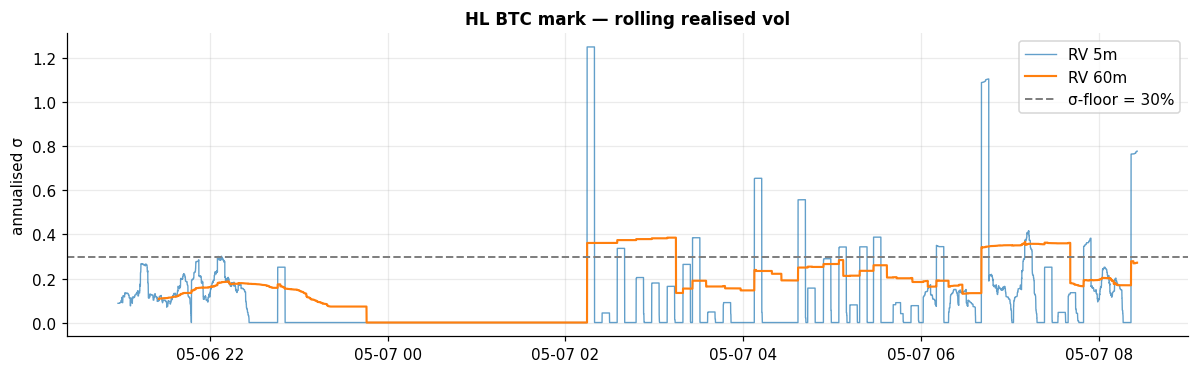

σ_60m median: 16.92% | σ_5m median: 0.00%


In [3]:
def q_model(S, K, sigma_annual, tau_years):
    """P(S_T >= K) under log-normal. Vectorised over S/sigma/tau (K scalar)."""
    S = np.asarray(S, dtype=float)
    sig = np.maximum(np.asarray(sigma_annual, dtype=float), 1e-9)
    tau = np.maximum(np.asarray(tau_years, dtype=float), 1e-12)
    d2 = (np.log(S / K) - 0.5 * sig**2 * tau) / (sig * np.sqrt(tau))
    return norm.cdf(d2)

def distance_to_strike(S, K, sigma_annual, tau_years):
    """Signed distance |S - K| / (S sigma sqrt(tau)). Sign convention:
    positive when YES (S > K) is the comfortable side."""
    S = np.asarray(S, dtype=float)
    sig = np.maximum(np.asarray(sigma_annual, dtype=float), 1e-9)
    tau = np.maximum(np.asarray(tau_years, dtype=float), 1e-12)
    return (S - K) / (S * sig * np.sqrt(tau))

# Realised vol estimators. Mark-price ticks are the right thing to differentiate
# (BBO mid is noisier and the binary settles on mark, not mid).
log_ret_1s = np.log(mark_1s).diff().dropna()
def rolling_rv(returns_1s, window_seconds):
    var = (returns_1s ** 2).rolling(window_seconds, min_periods=window_seconds // 2).sum()
    return np.sqrt(var) * np.sqrt(SEC_PER_YEAR / window_seconds)

rv_5m  = rolling_rv(log_ret_1s, 5 * 60)
rv_60m = rolling_rv(log_ret_1s, 60 * 60)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(rv_5m.index,  rv_5m,  lw=0.9, alpha=0.7, label='RV 5m')
ax.plot(rv_60m.index, rv_60m, lw=1.4,             label='RV 60m')
ax.axhline(STRAT['vol_floor'], ls='--', color='grey', label=f"σ-floor = {STRAT['vol_floor']:.0%}")
ax.set_ylabel('annualised σ'); ax.legend(); ax.set_title('HL BTC mark — rolling realised vol')
plt.tight_layout(); plt.show()
print(f"σ_60m median: {rv_60m.median():.2%} | σ_5m median: {rv_5m.median():.2%}")

## 3. `d` and `q_model` over the life of the most recent outcome

Pick the most-recently-expired (or active) outcome from `meta`, build the time series of `d` and `q_model`. The horizontal lines `d = 3, 1.5, 0` are the strategy's entry / stop / strike-touch thresholds.

Cycle: #50  K = 81,041  expiry = 2026-05-08 06:00 UTC


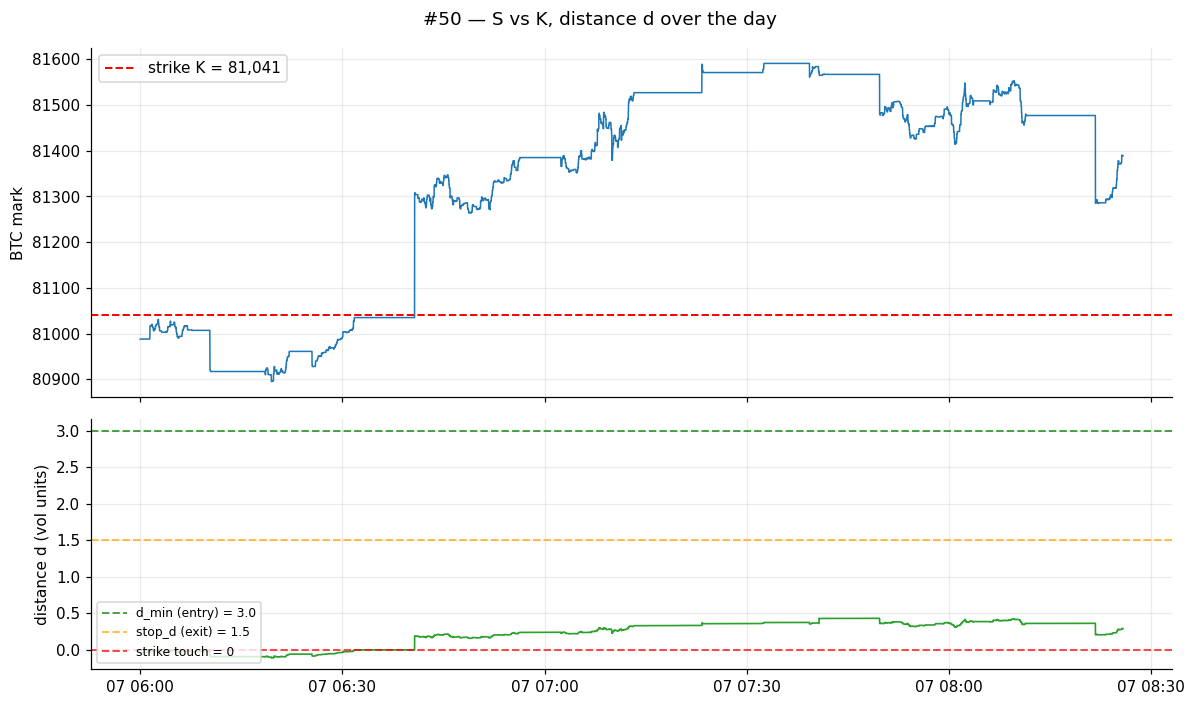

In [4]:
def build_d_series(K, expiry, mark_1s, rv_60m, vol_floor):
    """Construct a 1s-grid DataFrame of (S, sigma, tau_years, d, q) for the cycle ending at expiry."""
    s_grid = mark_1s.loc[:expiry]
    sigma  = rv_60m.reindex(s_grid.index).clip(lower=vol_floor).ffill().bfill()
    tau    = ((expiry - s_grid.index).total_seconds() / SEC_PER_YEAR).to_numpy().clip(min=1e-12)
    S_arr  = s_grid.to_numpy()
    sig_arr = sigma.to_numpy()
    d_arr   = (S_arr - K) / (S_arr * sig_arr * np.sqrt(tau))
    q_arr   = q_model(S_arr, K, sig_arr, tau)
    return pd.DataFrame({'S': S_arr, 'sigma': sig_arr, 'tau_years': tau,
                         'd': d_arr, 'q_yes': q_arr}, index=s_grid.index)

if meta.empty:
    print('No metadata yet — section skipped.')
    cycle_df = pd.DataFrame()
else:
    yes = meta[meta.side_idx == 0].dropna(subset=['strike','expiry']).sort_values('expiry').iloc[-1]
    K, T_exp, sym = float(yes.strike), pd.Timestamp(yes.expiry), yes.symbol
    print(f"Cycle: {sym}  K = {K:,.0f}  expiry = {T_exp:%Y-%m-%d %H:%M} UTC")
    cycle_df = build_d_series(K, T_exp, mark_1s, rv_60m, STRAT['vol_floor'])
    cycle_df = cycle_df.loc[T_exp - pd.Timedelta(days=1):T_exp]

    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.4, 1]})
    axes[0].plot(cycle_df.index, cycle_df.S, lw=1.0, color='C0')
    axes[0].axhline(K, ls='--', color='red', label=f'strike K = {K:,.0f}')
    axes[0].set_ylabel('BTC mark'); axes[0].legend()
    axes[1].plot(cycle_df.index, cycle_df.d, lw=1.1, color='C2')
    for level, col, txt in [(STRAT['d_min'], 'green', 'd_min (entry)'),
                            (STRAT['stop_d'], 'orange', 'stop_d (exit)'),
                            (0, 'red', 'strike touch')]:
        axes[1].axhline(level, ls='--', color=col, alpha=0.7, label=f'{txt} = {level}')
    axes[1].set_ylabel('distance d (vol units)'); axes[1].legend(loc='lower left', fontsize=8)
    fig.suptitle(f'{sym} — S vs K, distance d over the day')
    plt.tight_layout(); plt.show()
    cycle_df.tail(3)

## 4. Regime guards — vol-up tripwire + perp depth

A trade is allowed only if **all** the following hold (in addition to the `d` and price filters):

- `RV_5m / RV_60m ≤ 1.5` — no vol-regime change in progress.
- BTC perp top-10 level depth ≥ 50% of session-median — book is healthy enough that a benign trade can exit on stop without massive slippage.
- (Operational) Not within ±60 min of a scheduled macro release (CPI/FOMC/NFP/ECB). External calendar; not enforced in code.

The small outcome market is *not* a manipulation risk source: the maximum profit available to an attacker scales with the binary's open interest, while the cost to push BTC mark through the strike scales with HL perp depth. Until the binary is materially deeper than today's market, manipulation cost dominates by orders of magnitude. The depth check below is a guard against **uncorrelated** big BTC moves, not against directed manipulation.

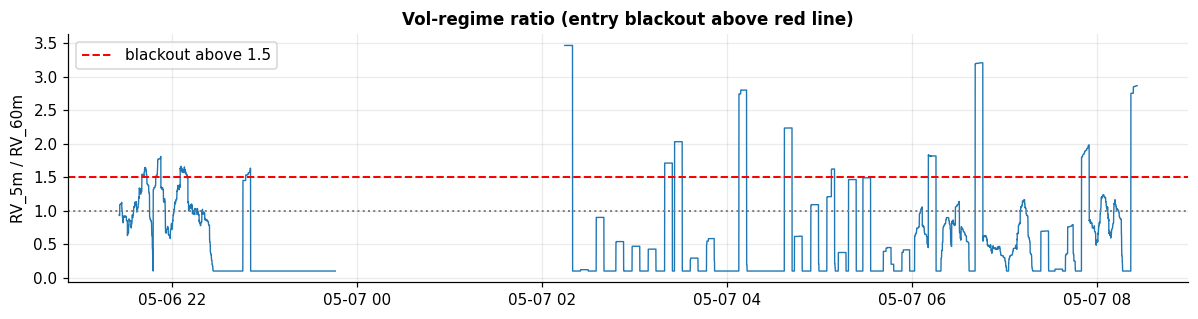

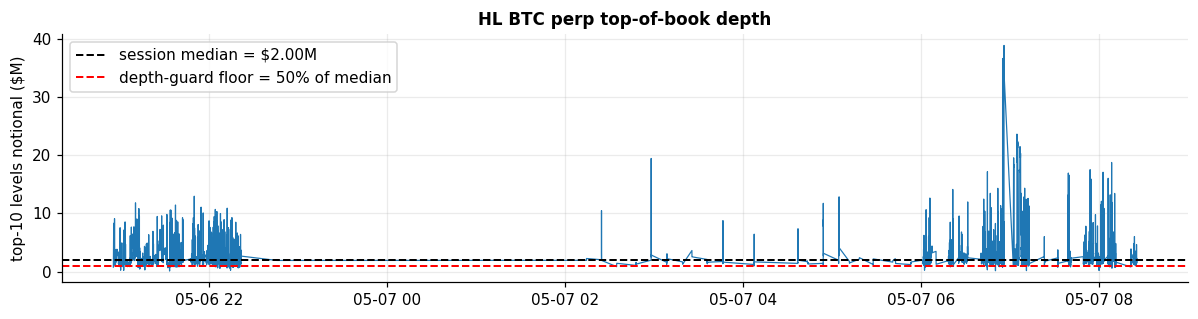

median top-10 depth: $1,996,083


In [5]:
# Vol-regime ratio
vol_ratio = (rv_5m / rv_60m).clip(0.1, 5)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(vol_ratio.index, vol_ratio, lw=0.9)
ax.axhline(STRAT['vol_ratio_max'], ls='--', color='red',
           label=f"blackout above {STRAT['vol_ratio_max']}")
ax.axhline(1.0, ls=':', color='grey')
ax.set_ylabel('RV_5m / RV_60m'); ax.legend(); ax.set_title('Vol-regime ratio (entry blackout above red line)')
plt.tight_layout(); plt.show()

# HL BTC perp top-of-book depth
book = load_df(f"""
    SELECT local_recv_ts, bid_px, bid_sz, ask_px, ask_sz
    FROM read_parquet('{glob_for(venue='hyperliquid', product_type='perp', event='book_snapshot', symbol='BTC')}',
                      hive_partitioning=true)
    ORDER BY local_recv_ts
""")
if book.empty:
    print('No HL perp book snapshots — depth guard cannot be calibrated yet.')
else:
    book['t'] = pd.to_datetime(book.local_recv_ts, unit='ns', utc=True)
    book = book.set_index('t').sort_index()
    def top_n_notional(px_arr, sz_arr, n=5):
        if px_arr is None or len(px_arr) == 0: return np.nan
        k = min(n, len(px_arr))
        return float(np.sum(np.array(px_arr[:k]) * np.array(sz_arr[:k])))
    book['bid_top5_usd'] = [top_n_notional(p, s) for p, s in zip(book.bid_px, book.bid_sz)]
    book['ask_top5_usd'] = [top_n_notional(p, s) for p, s in zip(book.ask_px, book.ask_sz)]
    book['top10_usd']    = book.bid_top5_usd + book.ask_top5_usd

    median_depth = book['top10_usd'].median()
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(book.index, book.top10_usd / 1e6, lw=0.8)
    ax.axhline(median_depth / 1e6, ls='--', color='black',
               label=f'session median = ${median_depth/1e6:.2f}M')
    ax.axhline(STRAT['perp_depth_min_frac'] * median_depth / 1e6, ls='--', color='red',
               label=f"depth-guard floor = {STRAT['perp_depth_min_frac']:.0%} of median")
    ax.set_ylabel('top-10 levels notional ($M)'); ax.legend()
    ax.set_title('HL BTC perp top-of-book depth')
    plt.tight_layout(); plt.show()
    print(f'median top-10 depth: ${median_depth:,.0f}')

## 5. Outcome-side BBO + the binary spread/depth guard

Loads the binary BBO if collected. If not yet present, this cell simply prints a status note — the recorder is already configured to capture `prediction_binary` BBO (see `config/symbols.yaml`); we just need it to accumulate cycles.

In [6]:
def load_binary_bbo(symbol):
    g = glob_for(venue='hyperliquid', product_type='prediction_binary', event='bbo', symbol=symbol)
    try:
        df = load_df(f"""
            SELECT local_recv_ts, bid_px, bid_sz, ask_px, ask_sz
            FROM read_parquet('{g}', hive_partitioning=true)
            WHERE bid_px > 0 AND ask_px > 0
            ORDER BY local_recv_ts
        """)
    except Exception as e:
        return pd.DataFrame()
    if df.empty: return df
    df['t']      = pd.to_datetime(df.local_recv_ts, unit='ns', utc=True)
    df['mid']    = 0.5 * (df.bid_px + df.ask_px)
    df['spread'] = df.ask_px - df.bid_px
    df['top1_usd'] = df.bid_sz * df.bid_px + df.ask_sz * df.ask_px
    return df.set_index('t')

if meta.empty:
    yes_bbo = no_bbo = pd.DataFrame()
    print('no metadata; skipping binary BBO load.')
else:
    pair = meta.dropna(subset=['expiry']).sort_values('expiry').iloc[-2:]   # last YES/NO pair
    yes_sym = pair[pair.side_idx == 0].symbol.iloc[0] if (pair.side_idx == 0).any() else None
    no_sym  = pair[pair.side_idx == 1].symbol.iloc[0] if (pair.side_idx == 1).any() else None
    yes_bbo = load_binary_bbo(yes_sym) if yes_sym else pd.DataFrame()
    no_bbo  = load_binary_bbo(no_sym)  if no_sym  else pd.DataFrame()
    print(f'YES {yes_sym}: {len(yes_bbo):,} BBO rows | NO {no_sym}: {len(no_bbo):,} BBO rows')

if yes_bbo.empty:
    print('Binary BBO not yet collected for this cycle. Re-run after recorder accumulates ≥ 1 day.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                             gridspec_kw={'height_ratios': [1.6, 1]})
    axes[0].plot(yes_bbo.index, yes_bbo.mid, lw=1.0, label=f'{yes_sym} mid')
    axes[0].fill_between(yes_bbo.index, yes_bbo.bid_px, yes_bbo.ask_px, alpha=0.15)
    axes[0].axhspan(*STRAT['price_band'], color='green', alpha=0.10, label='entry price band')
    axes[0].set_ylabel('YES price'); axes[0].set_ylim(0, 1); axes[0].legend(loc='lower right', fontsize=8)
    axes[1].plot(yes_bbo.index, yes_bbo.spread * 100, lw=0.9, color='C3', label='spread (¢)')
    axes[1].axhline(STRAT['binary_spread_max_cents'], ls='--', color='red',
                    label=f"max spread = {STRAT['binary_spread_max_cents']}¢")
    axes[1].set_ylabel('spread (cents)'); axes[1].legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{yes_sym} binary BBO with strategy bands')
    plt.tight_layout(); plt.show()

YES #50: 0 BBO rows | NO #51: 0 BBO rows
Binary BBO not yet collected for this cycle. Re-run after recorder accumulates ≥ 1 day.


## 6. Backtest scaffold — single-cycle simulator

Given a cycle (`K`, `expiry`, plus the `mark_1s`, `rv_60m`, `book`, `yes_bbo`, `no_bbo` series), the simulator walks the entry window once per second:

- **Gate check** at each tick `t`: `T_remaining ∈ window`, `d_t ≥ d_min`, `mid_t ∈ price_band`, `vol_ratio_t ≤ 1.5`, `perp_depth_t ≥ 0.5 × median`, binary spread `≤ 1.5¢`.
- On first pass: enter YES at `ask_t` for `trade_size_usd / ask_t` units. Place stop on `mid ≤ stop_price` AND `d ≤ stop_d` (whichever fires first).
- Walk forward; if any stop fires, exit at next bid; else hold to settlement.
- Realized PnL: at settlement `S_settle ≥ K → 1, else → 0`. Per-unit PnL = `(payoff - entry_ask)` if held; `(stop_bid - entry_ask)` if stopped.

The simulator emits one `TradeResult` per cycle (or `None` if no entry condition was met). Stop-loss sweeps and option comparisons reuse this primitive.

In [7]:
@dataclass
class TradeResult:
    cycle_symbol: str
    K: float
    expiry: pd.Timestamp
    entry_t: pd.Timestamp | None
    entry_ask: float | None
    exit_t:  pd.Timestamp | None
    exit_px: float | None
    exit_reason: str
    d_at_entry: float | None
    sigma_at_entry: float | None
    settle_S: float | None
    payoff: float | None
    pnl_per_unit: float | None
    units: float | None
    pnl_usd: float | None

def simulate_cycle(K, expiry, *, sym, mark_1s, rv_60m, book, yes_bbo, strat=STRAT) -> TradeResult | None:
    """Single late-YES trade with stop-loss. Returns None if no entry condition was ever met."""
    if yes_bbo.empty:
        return None

    window_start = expiry - pd.Timedelta(minutes=strat['entry_window_min'][0])
    window_end   = expiry - pd.Timedelta(minutes=strat['entry_window_min'][1])

    # Pre-compute decision-grid features on yes_bbo's timestamps.
    grid = yes_bbo[['bid_px','ask_px','mid','spread']].copy()
    grid = grid.loc[window_start:expiry]
    if grid.empty: return None

    # Align mark, sigma, depth, vol-ratio, no_mid onto grid via asof-merge (forward-fill).
    grid = grid.join(mark_1s.rename('S').reindex(grid.index, method='ffill'))
    grid['sigma']    = rv_60m.reindex(grid.index, method='ffill').clip(lower=strat['vol_floor'])
    grid['vol_ratio']= (rv_5m / rv_60m).reindex(grid.index, method='ffill')
    if not book.empty and 'top10_usd' in book.columns:
        depth_med = book['top10_usd'].median()
        grid['depth_ok'] = (book['top10_usd'].reindex(grid.index, method='ffill')
                            >= strat['perp_depth_min_frac'] * depth_med)
    else:
        grid['depth_ok'] = True
    grid['tau_yr'] = ((expiry - grid.index).total_seconds() / SEC_PER_YEAR).clip(lower=1e-12)
    grid['d']      = (grid.S - K) / (grid.S * grid.sigma * np.sqrt(grid.tau_yr))

    # Entry gate
    enter_mask = (
        (grid.index <= window_end)
        & (grid['d'] >= strat['d_min'])
        & (grid['mid'].between(*strat['price_band']))
        & (grid['vol_ratio'].fillna(1.0) <= strat['vol_ratio_max'])
        & (grid['spread'] <= strat['binary_spread_max_cents'] / 100.0)
        & (grid['depth_ok'])
    )
    if not enter_mask.any():
        return TradeResult(sym, K, expiry, None, None, None, None, 'no-entry',
                           None, None, None, None, None, None, None)

    entry_t   = grid.index[enter_mask][0]
    entry_row = grid.loc[entry_t]
    entry_ask = float(entry_row['ask_px'])
    units     = strat['trade_size_usd'] / entry_ask

    # Walk forward; check stop on every later tick.
    fwd = grid.loc[entry_t:]
    stop_mask = (fwd['mid'] <= strat['stop_price']) | (fwd['d'] <= strat['stop_d'])
    if stop_mask.any():
        exit_t   = fwd.index[stop_mask][0]
        exit_row = fwd.loc[exit_t]
        exit_px  = float(exit_row['bid_px'])         # exit on bid
        reason   = 'stop_d' if exit_row['d'] <= strat['stop_d'] else 'stop_price'
        # The settlement payoff doesn't matter once stopped; we record it for context.
    else:
        # Held to settlement.
        S_at_settle = float(mark_1s.asof(expiry))
        payoff = 1.0 if S_at_settle >= K else 0.0
        exit_t  = expiry
        exit_px = payoff
        reason  = 'settle_yes' if payoff == 1.0 else 'settle_no'

    pnl_per_unit = (exit_px - entry_ask) if reason.startswith('stop') else (exit_px - entry_ask)
    settle_S = float(mark_1s.asof(expiry)) if expiry in mark_1s.index or len(mark_1s.loc[:expiry])>0 else None
    return TradeResult(
        cycle_symbol=sym, K=K, expiry=expiry,
        entry_t=entry_t, entry_ask=entry_ask,
        exit_t=exit_t, exit_px=exit_px,
        exit_reason=reason,
        d_at_entry=float(entry_row['d']),
        sigma_at_entry=float(entry_row['sigma']),
        settle_S=settle_S,
        payoff=(1.0 if settle_S is not None and settle_S >= K else 0.0) if settle_S else None,
        pnl_per_unit=pnl_per_unit,
        units=units,
        pnl_usd=pnl_per_unit * units,
    )

# Run the simulator on the most-recent cycle (if data is present).
results: list[TradeResult] = []
if not meta.empty and not yes_bbo.empty:
    pair = meta.dropna(subset=['strike','expiry']).sort_values('expiry').iloc[-2:]
    yes  = pair[pair.side_idx == 0].iloc[0]
    res = simulate_cycle(float(yes.strike), pd.Timestamp(yes.expiry),
                         sym=yes.symbol, mark_1s=mark_1s, rv_60m=rv_60m,
                         book=book, yes_bbo=yes_bbo)
    if res is not None: results.append(res)
    print(res)
else:
    print('Simulator ready; need outcome BBO + multiple historical cycles before running.')

Simulator ready; need outcome BBO + multiple historical cycles before running.


## 7. Stop-loss sweep — what's the right `stop_price` and `stop_d`?

Vary one stop knob at a time over many cycles. Plot:

- **EV per trade** — does a tighter stop improve net EV (false stops vs catastrophic saves)?
- **95th-percentile loss** — drawdown control.
- **Hit rate** — fraction of trades that resolve YES (or stop) profitably.

Analytical reminder: a stop improves EV iff

$$\\frac{g}{f} > \\frac{q}{1-q} \\cdot \\frac{1-s}{s}$$

where `q` is true YES probability, `s` is stop price, `f` is false-stop rate (stopped on a YES that would have resolved), `g` is save rate (stopped on a NO that would have resolved). For `q=0.99, s=0.85` the bar is `g/f > 17`. For `q=0.95` it's `g/f > 3.3`. The lower your conviction, the more useful the stop.

In early validation `q` is uncertain, so the stop is correct even if EV-neutral — it bounds drawdown on a $1k bankroll.

In [8]:
def all_cycles_meta(meta_df):
    """Group meta by (outcome, expiry) and return one (sym_yes, K, expiry) per cycle."""
    if meta_df.empty: return []
    yes = meta_df[(meta_df.side_idx == 0)].dropna(subset=['strike','expiry'])
    return [(r.symbol, float(r.strike), pd.Timestamp(r.expiry)) for r in yes.itertuples()]

def sweep_stop_price(stop_grid, cycles, **base):
    rows = []
    for s in stop_grid:
        strat = {**STRAT, **base, 'stop_price': s}
        trades = []
        for sym, K, exp in cycles:
            yb = load_binary_bbo(sym)
            if yb.empty: continue
            tr = simulate_cycle(K, exp, sym=sym, mark_1s=mark_1s, rv_60m=rv_60m,
                                book=book, yes_bbo=yb, strat=strat)
            if tr is not None and tr.pnl_per_unit is not None:
                trades.append(tr)
        if not trades: continue
        pnls = np.array([t.pnl_per_unit for t in trades])
        rows.append({
            'stop_price': s,
            'n_trades': len(trades),
            'mean_pnl_per_unit': pnls.mean(),
            'p05_pnl': np.quantile(pnls, 0.05),
            'p95_pnl': np.quantile(pnls, 0.95),
            'win_rate': float((pnls > 0).mean()),
        })
    return pd.DataFrame(rows)

cycles = all_cycles_meta(meta)
print(f'cycles available: {len(cycles)}')

if len(cycles) >= 5 and not yes_bbo.empty:
    sweep = sweep_stop_price(np.linspace(0.70, 0.92, 12), cycles)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(sweep.stop_price, sweep.mean_pnl_per_unit, '-o'); axes[0].axhline(0, color='grey', lw=0.5)
    axes[0].set_title('mean PnL per unit'); axes[0].set_xlabel('stop_price')
    axes[1].plot(sweep.stop_price, sweep.p05_pnl, '-o', color='C3'); axes[1].axhline(0, color='grey', lw=0.5)
    axes[1].set_title('5th-pct PnL (left tail)'); axes[1].set_xlabel('stop_price')
    axes[2].plot(sweep.stop_price, sweep.win_rate, '-o', color='C2')
    axes[2].set_title('win rate'); axes[2].set_xlabel('stop_price'); axes[2].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
    print(sweep)
else:
    print('Need ≥ 5 cycles of binary BBO before stop-sweep is informative.')
    print('Today: cycles=', len(cycles), 'binary_bbo_present=', not yes_bbo.empty)

cycles available: 1
Need ≥ 5 cycles of binary BBO before stop-sweep is informative.
Today: cycles= 1 binary_bbo_present= False


## 8. Calibration plot — `d` vs realized YES rate

The central reliability check: if our `q_model` says 99%, does the market really resolve YES 99% of the time? Bucket cycles by `d` (measured at T-30min) and plot the empirical YES rate vs the modeled rate.

- A clean monotonic curve hugging the diagonal = `q_model` is calibrated and entry rule is sound.
- Persistent below-diagonal at high `d` = model is too confident; tighten `d_min` or use a higher σ proxy.
- Persistent above-diagonal at low `d` = market is too cautious; you have edge even at lower `d`.

This plot is the single most-important output of the first month of paper trading.

In [9]:
def calibration_table(cycles, eval_offset_min=30):
    """For each historical cycle, sample (d, q_model) at T - eval_offset and pair with realized YES."""
    rows = []
    for sym, K, exp in cycles:
        eval_t = exp - pd.Timedelta(minutes=eval_offset_min)
        if eval_t not in mark_1s.index and len(mark_1s.loc[:eval_t]) == 0:
            continue
        S      = float(mark_1s.asof(eval_t))
        sigma  = float(rv_60m.asof(eval_t)) if not pd.isna(rv_60m.asof(eval_t)) else STRAT['vol_floor']
        sigma  = max(sigma, STRAT['vol_floor'])
        tau    = max((exp - eval_t).total_seconds() / SEC_PER_YEAR, 1e-12)
        d_val  = (S - K) / (S * sigma * np.sqrt(tau))
        q_pred = float(q_model(np.array([S]), K, np.array([sigma]), np.array([tau]))[0])
        S_settle = float(mark_1s.asof(exp))
        rows.append({'symbol': sym, 'K': K, 'expiry': exp,
                     'S_eval': S, 'sigma_eval': sigma, 'd': d_val, 'q_pred': q_pred,
                     'S_settle': S_settle, 'realized_yes': int(S_settle >= K)})
    return pd.DataFrame(rows)

cal = calibration_table(cycles, eval_offset_min=30)
print(f'calibration sample size: {len(cal)}')

if len(cal) >= 10:
    # Bucket on q_pred (= calibration plot a la weather forecasters)
    cal['bucket'] = pd.cut(cal.q_pred, bins=[0, 0.5, 0.7, 0.85, 0.93, 0.97, 0.99, 1.0])
    grp = cal.groupby('bucket').agg(predicted=('q_pred','mean'),
                                    realized=('realized_yes','mean'),
                                    n=('symbol','size')).dropna()
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0,1], [0,1], 'k--', lw=0.7, label='perfect calibration')
    ax.scatter(grp.predicted, grp.realized, s=60 + 3*grp.n, alpha=0.7)
    for _, r in grp.iterrows():
        ax.annotate(f'n={int(r.n)}', (r.predicted, r.realized), xytext=(4,4), textcoords='offset points', fontsize=8)
    ax.set_xlabel('predicted q'); ax.set_ylabel('realized YES rate')
    ax.set_title(f'Reliability diagram @ T-{30}min  (n={len(cal)})')
    ax.legend(); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    plt.tight_layout(); plt.show()
    print(grp)
else:
    print('Need ≥ 10 historical cycles for a meaningful reliability diagram.')

calibration sample size: 1
Need ≥ 10 historical cycles for a meaningful reliability diagram.


## 9. Strategy options — priority ordering

Four candidate strategies, scored on (i) capital efficiency on a $1k bankroll, (ii) operational complexity, (iii) clarity of testable edge, (iv) tail-risk control. Run them in this order; do not advance to the next one until the current one has 20+ paper or live trades and a reliability diagram that holds.

### Tier 1 — START HERE

**Strategy A: Mark-anchored late YES with `d`-stop and price-stop**

*One-liner:* Manually enter YES in the last 30–15 min when `d ≥ 3`, regime is calm, BTC perp depth is healthy, binary spread is tight, mid is 93–99¢. Exit on `d ≤ 1.5` or mid `≤ 0.85`, whichever first.

- **Why first:** Settlement source (HL mark) is exactly what `q_model` predicts, so calibration is testable on the data we already collect for the perp. Single-leg, a single human can monitor 1 trade/day. Stop is informative without being a hedge — exactly your constraint.
- **Capital:** $100/trade (10% of $1k bankroll). Max loss per trade: ~$10–12 with stop at 0.85.
- **What to validate first:** the reliability diagram in section 8. If `q_pred ≈ 0.95` buckets resolve YES <90%, your σ proxy is wrong; refit before going live.
- **Operational footprint:** open `07` once a day in the last 60 min before 06:00 UTC; check the gates pass; place the trade; set a programmatic stop on HL UI; let it ride.

### Tier 2 — once Tier 1 has 20+ trades and calibration holds

**Strategy B: Cross-side pair (YES + cheap NO insurance)**

*One-liner:* Same entry as Strategy A, but also buy a small position of the *opposite* side (e.g. 1¢–4¢) so total max-loss is bounded by the insurance leg, eliminating the need to monitor a stop in real time.

- **Why second:** Same edge source as A but converts the trade from \"asymmetric with stop\" to \"defined-loss\". You give up a little EV (paying the insurance premium) for operational simplicity (no stop monitoring required).
- **When to switch from A→B:** if the stop-loss sweep in section 7 shows the binary-price stop has high false-trigger rate (`f` large), the implicit insurance from a cross-side hedge is mathematically equivalent to a perfect stop.
- **Capital:** $100 YES + ~$3–8 NO. Max loss bounded by `(YES_paid - 0)` minus `(NO_paid * 1)` recovered = predetermined.
- **Constraint:** requires the NO side to have liquidity. If NO is one-sided (no MM), this strategy is not available.

### Tier 3 — once binary microstructure is mapped

**Strategy C: Settlement-window passive provision**

*One-liner:* Post resting bids at 0.94–0.96 in the last 30 min instead of crossing the spread. Get filled only when an aggressor lifts you. Stop based on perp mark moving toward strike.

- **Why third:** Captures spread instead of paying it. Higher gross EV per filled trade. But it's *adversely-selected by construction* — you are most likely to fill exactly when someone has news that justifies the lower price.
- **Prerequisite analysis:** a Phase-P4-style markout study on the binary BBO (when a passive bid is hit, what does the binary mid do over the next 30s?). Until that markout is positive net of fees, do not provide.
- **Capital:** same $100, but expect lower fill rate so daily PnL is more variable.
- **Risk gotcha:** during HL outages (see the recorder's reconnect circuit-breaker — the 2026-05-06 settlement saw 478 reconnects and a 12-min blackout) a resting order can be filled while you have no working stop. **Do not pursue this until automated stop-monitoring is in place.**

### Tier 4 — speculative, defer until ≥3 months of data

**Strategy D: Settlement-pin / gamma-magnet directional**

*One-liner:* Predict whether HL BTC mark \"magnets\" toward the strike near 06:00 UTC (a known options gamma-hedging effect) and pre-position accordingly. Pure microstructure / order-flow trade.

- **Why last:** Requires the binary to be liquid enough that delta-hedgers exist; today's HIP-4 binary is too small. Only run this once binary OI is at least 10× current.
- **Inputs needed:** order-flow imbalance in the last 15 min, perp depth asymmetry near strike, end-of-day funding-print history. None of these we measure today.

---

### Concrete starter parameters for Strategy A (the one to begin with)

| Parameter | Starting value | How we know it's right |
|---|---|---|
| Entry window | T-30min to T-5min | Slippage + edge-decay analysis from collected BBO |
| `d_min` | 3.0 | Reliability diagram in section 8 |
| Price band | [0.93, 0.99] | Below 93¢ payoff doesn't cover frictions; above 99¢ insufficient liquidity |
| Vol-ratio max | 1.5 | Section 4 (RV_5m / RV_60m) |
| BTC perp depth min | 50% of session-median | Section 4 depth chart |
| Binary spread max | 1.5¢ | Section 5 |
| Position size | $100 (10% of bankroll) | Bump to $200 after 20 paper or 10 live wins that hit calibration target |
| Stop A: `d`-stop | exit if d ≤ 1.5 | Sweep in section 7 |
| Stop B: price-stop | exit if mid ≤ 0.85 | Sweep in section 7 |
| Macro blackout | ±60 min around CPI/FOMC/NFP/ECB | External calendar |

### What this notebook needs to evolve into a live signal

1. **Outcome-side BBO/book/trade data** — recorder is already configured (`config/symbols.yaml`); we just need accumulation. After ~7 cycles section 7's stop sweep starts being informative; after ~20 cycles section 8's reliability diagram is statistically meaningful.
2. **Per-trade journal** — a small parquet at `data/journal/strategy=late-yes/...parquet` capturing `(entry_t, d, S, K, sigma, mid, exit_reason, pnl)` for every paper and live trade.
3. **Daily 06:00 UTC report** — schedule this notebook to run headlessly at 06:01 UTC and emit `docs/reports/late-yes-YYYY-MM-DD.md` with the cycle's chart pack + the reliability diagram refreshed.

### What to **not** do

- Do not enter inside the last 5 minutes — gamma is too violent and slippage compounds.
- Do not enter at price ≥ 0.995. Net edge is below fee floor and slippage on exit is unbounded.
- Do not trade across multiple cycles in one day (until 1 cycle per day produces calibrated results).
- Do not skip the macro-event blackout — vol spikes and depth collapse simultaneously.